# Youtube Music Analysis Project Part 2: Music Analysis

This notebook explores and analyses my YouTube watch history using Python and pandas. this notebook will be performing exploratory data analysis with a focus on music listening habits

## Analysis Goals

Youtube Recap already records the following metrics (which this notebook will also attempt to record):

- Most listened to songs/Artists/Genres/Musical Moods
- Total Listening Time

However, in my project I will also attempt to record, analyse and visualise other statistics due to the Google Takeout data containing exact timestamps of when a video was viewed/listened, we can use this to analyse:
- Listening Habits - When exactly do I listen to music
- Listening Sessions - How long/How many songs do I listen to in a given session
- Song loyalty - How many times do I listen to the same song? How often do i listen to new songs?
- Song trends - How many times do I listen to songs over time

What do I listen to?
Songs, artists, genres, favourites, total listening time.

When do I listen?
Hour, day, weekday/weekend, sessions, heatmaps.

How do I listen?
Repeats, diversity, session length, concentration.

How does my listening change?
Discovery, trends, obsessions, fading songs, changing artists/genres.

## Basic Analysis

Retrieving:
1. Total number of music plays
2. Number of unique videos listened to
3. Number of unique channels

In [1]:
from string.templatelib import convert

import pandas as pd

music_dataframe = pd.read_csv(r"C:\Users\MsnSi\PycharmProjects\Youtube_Music_Analysis\data\processed\music_history.csv")

music_dataframe.head()

,title,channel,watched_at,video_url,video_ids,channel_id,video_duration,classification,classification_reason,classification_evidence
0,Halo Main Theme | Soundtrack | The Bands of HM...,The Bands of HM Royal Marines,2026-07-07 18:53:59,https://www.youtube.com/watch?v=oQ8FZDm8pso,oQ8FZDm8pso,UCJ_cJSfxvUG3H-Q_5ylW7xg,PT3M8S,confirmed_music,music_channel,NaN
1,Funniest bit of British comedy,MillerTime,2026-07-07 19:43:51,https://www.youtube.com/watch?v=34mk2F4iff4,34mk2F4iff4,UCcEBjovm2se1eRwvnwitz_Q,PT2M11S,probable_music,youtube_music_category_only,NaN
2,"Blackbear - ""Deadroses"" OFFICIAL VERSION",StrictlyHits,2026-07-08 14:54:39,https://www.youtube.com/watch?v=8amLwmLp9pg,8amLwmLp9pg,UCvTLh2gYXW3P6UzT1W9kegw,PT3M6S,confirmed_music,music_channel,NaN
3,Red （Lofi Ver.）,Mori Calliope - Topic,2026-07-08 15:11:31,https://www.youtube.com/watch?v=4dkup34LO6E,4dkup34LO6E,UCT6fzkIIQuAQIiJK3tt-keg,PT4M25S,confirmed_music,music_channel,NaN
4,It's Going Down Now,Azumi Takahashi - Topic,2026-07-10 18:21:02,https://www.youtube.com/watch?v=2KuWjZD6PBA,2KuWjZD6PBA,UCPvaDaeCvULM4x1HOAwBcOw,PT3M7S,confirmed_music,music_channel,NaN


In [2]:
music_plays = len(music_dataframe)
unique_videos = music_dataframe["video_ids"].nunique()
unique_channels = music_dataframe["channel_id"].nunique()

print(f"In the DataFrame, there are:\n"
      f"{music_plays} number of plays\n"
      f"{unique_videos} unique videos\n"
      f"{unique_channels} unique channels\n")

In the DataFrame, there are:
3097 number of plays
279 unique videos
168 unique channels



Next, we'll retrieve the most commonly played videos and channels

In [3]:
video_counts = music_dataframe["video_ids"].value_counts()
channel_counts = music_dataframe["channel"].value_counts()
title_counts = music_dataframe["title"].value_counts()

print(title_counts.head(10))
print(channel_counts.head(10))


title
Nightcore / Sped Up → Ai Đưa Em Về (Rock Version/Cover)                      484
Why Do I (with Hatsune Miku)                                                 441
奏  - スキマスイッチ (Cover) / VESPERBELL ヨミ                                         256
Imagine Dragons - Take Me To The Beach (feat. Ado) (Official Lyric Video)    196
アンノウン・マザーグース（cover）/ 相沢                                                      144
【歌ってみた】喜劇 カバー 羊羊｜フルVer. #星野源 #SPY_FAMILY                                     144
Ms. VICTORIA                                                                 121
Umapyoi Celebrity                                                             81
I'm a chud song (Kasane Teto Cover)                                           64
【Ado】オールナイトレディオ                                                               64
Name: count, dtype: int64
channel
Sen                                 490
Set It Off                          468
VESPERBELL_YM                       256
ImagineDragonsVEVO            

Interestingly, the results surprised me slightly, that Why Do I, wasn't the most frequently played song as was recorded in my actual June - August Youtube Recap, although of course, this Data set is different, going from the 7th of July to the 7th of September,

In [4]:
top_1_plays = title_counts.head(1).sum()
top_3_plays = title_counts.head(3).sum()
top_5_plays = title_counts.head(5).sum()
top_10_plays = title_counts.head(10).sum()
top_25_plays = title_counts.head(25).sum()

top_1_plays_percentage = (top_1_plays / music_plays) * 100
top_3_plays_percentage = (top_3_plays / music_plays) * 100
top_5_plays_percentage = (top_5_plays / music_plays) * 100
top_10_plays_percentage = (top_10_plays / music_plays) * 100
top_25_plays_percentage = (top_25_plays / music_plays) * 100

print(f"The Top 1 Song has {top_1_plays} plays with {top_1_plays_percentage:.1f}% of plays\n"
      f"The Top 3 Songs have {top_3_plays} plays with {top_3_plays_percentage:.1f}% of plays\n"
      f"The Top 5 Songs have {top_5_plays} plays with {top_5_plays_percentage:.1f}% of plays\n"
      f"The Top 10 Songs have {top_10_plays} plays with {top_10_plays_percentage:.1f}% of plays\n"
      f"The Top 25 Songs have {top_25_plays} plays with {top_25_plays_percentage:.1f}% of plays\n")

The Top 1 Song has 484 plays with 15.6% of plays
The Top 3 Songs have 1181 plays with 38.1% of plays
The Top 5 Songs have 1521 plays with 49.1% of plays
The Top 10 Songs have 1995 plays with 64.4% of plays
The Top 25 Songs have 2461 plays with 79.5% of plays



Interestingly, the most played songs take up a very large amount of the listening amount


In [5]:
music_dataframe[["title", "video_duration"]].head()

,title,video_duration
0,Halo Main Theme | Soundtrack | The Bands of HM...,PT3M8S
1,Funniest bit of British comedy,PT2M11S
2,"Blackbear - ""Deadroses"" OFFICIAL VERSION",PT3M6S
3,Red （Lofi Ver.）,PT4M25S
4,It's Going Down Now,PT3M7S


## Analysing Listening Habits

Firstly before anything else, one of the pieces of data within our dataset is the duration of the video, but it is currently in the form PTxHyMzS which we'll need to convert into an actual duration if we want to use it

In [6]:
import re
duration_1 = "PT4M52S"
duration_2 = "PT1H2M14S"
duration_3 = "PT47S"
duration_4 = "PT5M"

durations = [duration_1, duration_2, duration_3, duration_4]


def convert_ISO8601_to_string(duration):
    match = re.match(
        r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?",
        duration)

    return match.groups()

def convert_video_duration_to_seconds(duration):
    ISO_converted_string = convert_ISO8601_to_string(duration)

    seconds = 0
    x = 0
    multiplers = [3600, 60, 1]

    for x in range(3):
        if ISO_converted_string[x] is None:
            continue
        else:
            seconds += int(ISO_converted_string[x]) * multiplers[x]

    return seconds

for duration in durations:
    print(f"Converted {duration} into {convert_video_duration_to_seconds(duration)} seconds\n")


Converted PT4M52S into 292 seconds

Converted PT1H2M14S into 3734 seconds

Converted PT47S into 47 seconds

Converted PT5M into 300 seconds



In [7]:
music_dataframe["duration_seconds"] = (
    music_dataframe["video_duration"].apply(convert_video_duration_to_seconds)
)

print(music_dataframe["duration_seconds"].describe())

print(
    music_dataframe[
        ["title", "video_duration", "duration_seconds"]
    ].head(10)
)

count    3097.000000
mean      308.775266
std       775.822480
min        10.000000
25%       168.000000
50%       215.000000
75%       274.000000
max      7311.000000
Name: duration_seconds, dtype: float64
                                               title video_duration  \
0  Halo Main Theme | Soundtrack | The Bands of HM...         PT3M8S   
1                     Funniest bit of British comedy        PT2M11S   
2           Blackbear - "Deadroses" OFFICIAL VERSION         PT3M6S   
3                                    Red （Lofi Ver.）        PT4M25S   
4                                It's Going Down Now         PT3M7S   
5                                It's Going Down Now         PT3M7S   
6                                It's Going Down Now         PT3M7S   
7         Official髭男dism - Pretender［Official Video］        PT5M36S   
8         Official髭男dism - Pretender［Official Video］        PT5M36S   
9         Official髭男dism - Pretender［Official Video］        PT5M36S   

   duration

In [8]:
def convert_seconds_to_HMS(seconds):
    seconds = int(seconds)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    return f"{hours:02d}H:{minutes:02d}M:{seconds:02d}S"


total_listening_seconds = music_dataframe["duration_seconds"].sum()
total_listening_time = convert_seconds_to_HMS(total_listening_seconds)

print(f"Total listening time in seconds: {total_listening_seconds}s\n"
      f"Total listening time: {total_listening_time}")


Total listening time in seconds: 956277s
Total listening time: 265H:37M:57S


265 Hours is quite a lot of time for listening, its likley we have some kind of outliers.

In [9]:
music_dataframe[
    ["title", "video_duration", "duration_seconds"]
].sort_values("duration_seconds", ascending=False).head(10)

,title,video_duration,duration_seconds
564,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
565,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
569,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
568,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
567,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
566,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
342,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
343,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
696,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311
695,Prison Labor - Persona 5 Royal OST [Extended],PT2H1M51S,7311


Yep, this video is about 2 hours long, but my last listen only ended about 10 minutes in, we'll need to fix this

In [10]:
long_videos = music_dataframe[
    music_dataframe["duration_seconds"] > 600
]

print(long_videos["title"].value_counts())

long_video_seconds = long_videos["duration_seconds"].sum()

print(convert_seconds_to_HMS(long_video_seconds))

title
Prison Labor - Persona 5 Royal OST [Extended]                                                       36
ヨルシカをメドレーにして1人でバンドしてみた -Yorushika Medley One man Band Cover                                          4
that one dinky ass kirby song except it loops                                                        1
Pokemon Black and White - Low HP Music EXTENDED                                                      1
57 minutes of silence occasionally interrupted by weird route cue                                    1
Coldplay – Viva La Vida Loop on Cat Piano ($1000 request)                                            1
【YOASOBI🌷】全有名曲メドレー ｜Study with me｜Work with me｜リラックスタイム｜安眠・癒し・作業用BGM｜勉強用BGM｜AnnieChan_playlist ⑤     1
星街すいせいメドレーを一人でバンド組んで歌ってみた                                                                            1
【アコギ】ヨルシカ Acoustic Guitarメドレー2【全12曲】                                                                 1
POV: you're in love with a memory | Playlist                       

Because YouTube Watch History records that a video was watched but not
the exact watch duration, total listening time cannot be measured exactly.

The raw estimate assumes every music video was watched in full.

For this personal dataset, I made a note of the music tracks that were noted in this code and manually adjusted their duration to my recollection These
adjustments are therefore specific to this dataset and are not intended as a general listening-time algorithm.

In [11]:
duration_exceptions = {
    "Prison Labor - Persona 5 Royal OST [Extended]": 10 * 60,
    "that one dinky ass kirby song except it loops": 12 * 60,
    "POV: you're in love with a memory | Playlist": 2 * 60,
    "Mobile Suit Gundam Iron Blooded Orphans Urdr Hunt OST - Red vs Blue [Extended]": 2 * 60,
    "At Bantam 🍷✨ Yakuza Bar/Cafe OST Mix": 5 * 60,
    "Pokemon Black and White - Low HP Music EXTENDED": 2 * 60,
    "57 minutes of silence occasionally interrupted by weird route cue": 2 * 60,
    "Go To Sleep, She Isn't Coming Back.": 2 * 60,
    "Coldplay – Viva La Vida Loop on Cat Piano ($1000 request)": 2 * 60,
    "【YOASOBI🌷】全有名曲メドレー ｜Study with me｜Work with me｜リラックスタイム｜安眠・癒し・作業用BGM｜勉強用BGM｜AnnieChan_playlist ⑤": 10 * 60
}
music_dataframe["adjusted_duration_seconds"] = (
    music_dataframe["duration_seconds"].copy()
)

for title, adjusted_duration in duration_exceptions.items():
    music_dataframe.loc[
        music_dataframe["title"] == title,
        "adjusted_duration_seconds"
    ] = adjusted_duration

total_adjusted_seconds = music_dataframe["adjusted_duration_seconds"].sum()

total_adjusted_listening_time = convert_seconds_to_HMS(
    total_adjusted_seconds
)

print(f"Raw estimated listening time: "
      f"{convert_seconds_to_HMS(total_listening_seconds)}")

print(f"Adjusted estimated listening time: "
      f"{total_adjusted_listening_time}")

Raw estimated listening time: 265H:37M:57S
Adjusted estimated listening time: 193H:01M:54S


### Using the "watched_at" metric

### Listening Habits by Hour

In [12]:
print(music_dataframe["watched_at"].dtype)
print(music_dataframe["watched_at"].head())

music_dataframe["watched_at"] = pd.to_datetime(music_dataframe["watched_at"])

print(music_dataframe["watched_at"].dt.hour)



str
0    2026-07-07 18:53:59
1    2026-07-07 19:43:51
2    2026-07-08 14:54:39
3    2026-07-08 15:11:31
4    2026-07-10 18:21:02
Name: watched_at, dtype: str
0       18
1       19
2       14
3       15
4       18
        ..
3092    10
3093    10
3094    10
3095    10
3096    11
Name: watched_at, Length: 3097, dtype: int32


In [13]:
print(music_dataframe["watched_at"].dt.hour.value_counts().sort_index())

watched_at
0     148
1     127
2      43
3     114
4      13
5     101
6      10
7     129
8     214
9     271
10    198
11    145
12    142
13    150
14    132
15     35
16     72
17     54
18     39
19    100
20     38
21    163
22    322
23    337
Name: count, dtype: int64


This data is quite interesting, unsurprisingly during the summer, my listening times are mostly centered around the late evening (compared to a time like now during semester where I'd say it'd be a lot more spread out due to commuting and working in college) , interstingly, the early morning (from 7 until 2) was also a frequent listening time, however, when we consider that I was in Hong Kong and Japan for 2 weeks, it makes sense that during that period, my frequent listening period behaviorally is the same

In [14]:
music_dataframe["hour"] = music_dataframe["watched_at"].dt.hour
listening_time_by_hour = (
    music_dataframe
    .groupby("hour")["adjusted_duration_seconds"]
    .sum()
)

listening_time_by_hour_HMS = listening_time_by_hour.apply(
    convert_seconds_to_HMS
)

print(listening_time_by_hour_HMS)


hour
0     09H:40M:38S
1     07H:50M:03S
2     02H:10M:09S
3     06H:01M:02S
4     00H:28M:14S
5     07H:19M:59S
6     00H:26M:59S
7     09H:01M:50S
8     12H:56M:44S
9     16H:47M:58S
10    13H:05M:07S
11    09H:08M:30S
12    09H:55M:23S
13    09H:40M:51S
14    07H:52M:46S
15    02H:44M:45S
16    03H:53M:21S
17    03H:22M:47S
18    02H:13M:32S
19    06H:35M:57S
20    03H:06M:34S
21    09H:07M:36S
22    18H:29M:58S
23    21H:01M:11S
Name: adjusted_duration_seconds, dtype: str


#### Listening habits by Day

In [15]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
music_dataframe["day"] = music_dataframe["watched_at"].dt.day_name()

plays_by_day = (
    music_dataframe["day"]
    .value_counts()
    .reindex(day_order)
)

print(plays_by_day)


day
Monday       518
Tuesday      274
Wednesday    409
Thursday     394
Friday       533
Saturday     552
Sunday       417
Name: count, dtype: int64


To be honest (especially given the summer where I had no real obligations). I wouldn't be surprised that each day of the week had a similar enough count, but I still think it is useful information to retain

#### Listening habits by Date

In [16]:
music_dataframe["date_listened"] =  music_dataframe["watched_at"].dt.date

plays_by_date = (
    music_dataframe["date_listened"]
    .value_counts().sort_index()
)

print(plays_by_date)





date_listened
2026-07-07      2
2026-07-08      2
2026-07-10     24
2026-07-11     58
2026-07-12     38
2026-07-13     34
2026-07-14     18
2026-07-15     42
2026-07-16      1
2026-07-17     20
2026-07-18     12
2026-07-19     31
2026-07-20      3
2026-07-21     22
2026-07-22      3
2026-07-23     30
2026-07-24     22
2026-07-25     69
2026-07-26     38
2026-07-27     30
2026-07-28    104
2026-07-29     65
2026-07-30     27
2026-07-31      6
2026-08-01     82
2026-08-02     28
2026-08-03    123
2026-08-04     10
2026-08-05     20
2026-08-06     11
2026-08-07      1
2026-08-08     96
2026-08-09      8
2026-08-10     17
2026-08-11     68
2026-08-12     85
2026-08-13    108
2026-08-14    114
2026-08-15     84
2026-08-16    102
2026-08-17     96
2026-08-19     95
2026-08-20     24
2026-08-21     73
2026-08-22     89
2026-08-23     70
2026-08-24     86
2026-08-25     50
2026-08-26     81
2026-08-27     82
2026-08-28    152
2026-08-29     57
2026-08-30     97
2026-08-31     54
2026-09-02    

## Analysing Listening Sessions

Definiton: A new listening session begins when more than 30 minutes passes between two music watch events.

- 22:01  Song A
- 22:05  Song B
- 22:09  Song C
- 22:27  Song D

             ↓ 38-minute gap
- 23:05  Song E    ← new session
- 23:09  Song F

### Defining the Sessions field in the dataset

In [17]:
print(
    music_dataframe[
        ["watched_at"]
    ].head(10)
)

print(
    music_dataframe["watched_at"]
    .diff()
    .head(10)
)

           watched_at
0 2026-07-07 18:53:59
1 2026-07-07 19:43:51
2 2026-07-08 14:54:39
3 2026-07-08 15:11:31
4 2026-07-10 18:21:02
5 2026-07-10 18:21:02
6 2026-07-10 18:21:02
7 2026-07-10 19:08:33
8 2026-07-10 19:08:33
9 2026-07-10 19:08:33
0               NaT
1   0 days 00:49:52
2   0 days 19:10:48
3   0 days 00:16:52
4   2 days 03:09:31
5   0 days 00:00:00
6   0 days 00:00:00
7   0 days 00:47:31
8   0 days 00:00:00
9   0 days 00:00:00
Name: watched_at, dtype: timedelta64[us]


In [18]:
time_gaps = music_dataframe["watched_at"].diff()

new_session = time_gaps > pd.Timedelta(minutes=30)

print(
    music_dataframe.loc[
        new_session,
        ["watched_at", "title"]
    ].head(20)
)

new_session.iloc[0] = True


print(new_session.sum())


             watched_at                                              title
1   2026-07-07 19:43:51                     Funniest bit of British comedy
2   2026-07-08 14:54:39           Blackbear - "Deadroses" OFFICIAL VERSION
4   2026-07-10 18:21:02                                It's Going Down Now
7   2026-07-10 19:08:33         Official髭男dism - Pretender［Official Video］
16  2026-07-10 19:40:05  「Yona Yona Journey / TAKU INOUE & Mori Calliop...
25  2026-07-10 23:23:23                           「ツギハギスタッカート」歌ってみた【＊なみりん】
57  2026-07-11 01:29:06  Midnight Grand Orchestra『Moonlightspeed 』Music...
61  2026-07-11 21:54:01                       Why Do I (with Hatsune Miku)
86  2026-07-12 01:05:33                                    Why do we stay?
87  2026-07-12 02:15:33  Set It Off - Why Do I (with Hatsune Miku) [Spe...
88  2026-07-12 02:50:32  Perception Check (Official Music Video) - Tom ...
91  2026-07-12 03:57:50  Thought Crime (Yorushika) ♡ English Cover【rach...
92  2026-07-12 04:40:03  

### Exploring the Sessions

#### Number of Songs per Session

In [19]:
music_dataframe["session_id"] = new_session.cumsum()

songs_per_session = (
    music_dataframe
    .groupby("session_id")
    .size()
)

print(songs_per_session)
print(f"Average Songs per session: {songs_per_session.mean():.1f} \n"
      f"Highest number of songs in a session: {songs_per_session.max()}\n")

songs_per_session.describe()

session_id
1       1
2       1
3       2
4       3
5       9
       ..
177    47
178     4
179     1
180     5
181    75
Length: 181, dtype: int64
Average Songs per session: 17.1 
Highest number of songs in a session: 112



count    181.000000
mean      17.110497
std       24.230581
min        1.000000
25%        2.000000
50%        7.000000
75%       21.000000
max      112.000000
dtype: float64

#### Listening time per Session

In [20]:
time_per_session = (
    music_dataframe
    .groupby("session_id")["adjusted_duration_seconds"]
    .sum()
)

print(time_per_session.mean())
print(f"Average time per session: {convert_seconds_to_HMS(time_per_session.mean())}")

3839.303867403315
Average time per session: 01H:03M:59S


#### Finding the longest session

In [21]:
largest_session_id = songs_per_session.idxmax()

songs_per_session.max()

print(convert_seconds_to_HMS(time_per_session.loc[largest_session_id]))
print(f"Largest session listened was number {songs_per_session.idxmax()}")
music_dataframe[
    music_dataframe["session_id"] == songs_per_session.idxmax()
][["watched_at", "title"]]

06H:17M:41S
Largest session listened was number 92


,watched_at,title
815,2026-08-03 08:13:22,Why Do I (with Hatsune Miku)
816,2026-08-03 08:13:22,Why Do I (with Hatsune Miku)
817,2026-08-03 08:13:22,Why Do I (with Hatsune Miku)
818,2026-08-03 08:13:22,Why Do I (with Hatsune Miku)
819,2026-08-03 08:13:22,Why Do I (with Hatsune Miku)
...,...,...
922,2026-08-03 09:42:04,【Ado】ヒバナ 歌いました
923,2026-08-03 09:45:28,Deep Indigo -piano and drums arrange- ♡ Englis...
924,2026-08-03 09:45:28,Deep Indigo -piano and drums arrange- ♡ Englis...
925,2026-08-03 09:49:29,ヨルシカ - 八月、某、月明かり（OFFICIAL VIDEO）


In [22]:
longest_session_id = time_per_session.idxmax()
longest_session_seconds = time_per_session.max()

print(
    convert_seconds_to_HMS(longest_session_seconds)
)

print(f"Longest Session listened was {longest_session_id}")
music_dataframe[
    music_dataframe["session_id"] == longest_session_id
][["watched_at", "title", "adjusted_duration_seconds"]]

06H:41M:55S
Longest Session listened was 129


,watched_at,title,adjusted_duration_seconds
1561,2026-08-16 22:32:21,Nightcore / Sped Up → Ai Đưa Em Về (Rock Versi...,215
1562,2026-08-16 22:32:21,Nightcore / Sped Up → Ai Đưa Em Về (Rock Versi...,215
1563,2026-08-16 22:32:21,Nightcore / Sped Up → Ai Đưa Em Về (Rock Versi...,215
1564,2026-08-16 22:32:21,Nightcore / Sped Up → Ai Đưa Em Về (Rock Versi...,215
1565,2026-08-16 22:32:21,Nightcore / Sped Up → Ai Đưa Em Về (Rock Versi...,215
...,...,...,...
1653,2026-08-16 23:43:44,【Ado】踊,209
1654,2026-08-16 23:43:44,【Ado】踊,209
1655,2026-08-16 23:43:44,【Ado】踊,209
1656,2026-08-16 23:51:04,tuki.『晩餐歌』Official Music Video,220


In [23]:
total_sessions = music_dataframe["session_id"].nunique()

average_events_per_session = songs_per_session.mean()
median_events_per_session = songs_per_session.median()
largest_session_events = songs_per_session.max()

average_session_seconds = time_per_session.mean()
longest_session_seconds = time_per_session.max()

print(f"Total sessions: {total_sessions}")
print(f"Average events per session: {average_events_per_session:.1f}")
print(f"Median events per session: {median_events_per_session:.1f}")
print(f"Largest session: {largest_session_events} events")

print(
    "Average estimated session listening time:",
    convert_seconds_to_HMS(average_session_seconds)
)

print(
    "Longest estimated session listening time:",
    convert_seconds_to_HMS(longest_session_seconds)
)

Total sessions: 181
Average events per session: 17.1
Median events per session: 7.0
Largest session: 112 events
Average estimated session listening time: 01H:03M:59S
Longest estimated session listening time: 06H:41M:55S


### Listening habits over time

In [24]:
music_dataframe["week"] = (
    music_dataframe["watched_at"]
    .dt.to_period("W")
)

print(
    music_dataframe[
        ["watched_at", "week", "title"]
    ].head()
)

           watched_at                   week  \
0 2026-07-07 18:53:59  2026-07-06/2026-07-12   
1 2026-07-07 19:43:51  2026-07-06/2026-07-12   
2 2026-07-08 14:54:39  2026-07-06/2026-07-12   
3 2026-07-08 15:11:31  2026-07-06/2026-07-12   
4 2026-07-10 18:21:02  2026-07-06/2026-07-12   

                                               title  
0  Halo Main Theme | Soundtrack | The Bands of HM...  
1                     Funniest bit of British comedy  
2           Blackbear - "Deadroses" OFFICIAL VERSION  
3                                    Red （Lofi Ver.）  
4                                It's Going Down Now  


In [26]:
weekly_song_counts = (
    music_dataframe
    .groupby(["week", "title"])
    .size()
)

print(weekly_song_counts)

week                   title                                                       
2026-07-06/2026-07-12  Blackbear - "Deadroses" OFFICIAL VERSION                         1
                       Funniest bit of British comedy                                   1
                       Halo Main Theme | Soundtrack | The Bands of HM Royal Marines     1
                       It's Going Down Now                                              3
                       Kings - Jose Pavli | Project Wingman Soundtrack (2020)           1
                                                                                       ..
2026-09-07/2026-09-13  Why Do I (with Hatsune Miku)                                    21
                       monitoring (deco*27) ♥ english cover【rachie】モニタリング               1
                       「Yona Yona Journey / TAKU INOUE & Mori Calliope」MUSIC VIDEO      4
                       【Ado】ギラギラ                                                        4
                

In [27]:
print(weekly_song_counts.head(20))
print(weekly_song_counts.index)

week                   title                                                       
2026-07-06/2026-07-12  Blackbear - "Deadroses" OFFICIAL VERSION                         1
                       Funniest bit of British comedy                                   1
                       Halo Main Theme | Soundtrack | The Bands of HM Royal Marines     1
                       It's Going Down Now                                              3
                       Kings - Jose Pavli | Project Wingman Soundtrack (2020)           1
                       Mechanized Memories                                              3
                       Midnight Grand Orchestra『Moonlightspeed 』Music Video             4
                       Official髭男dism - Pretender［Official Video］                       6
                       Perception Check (Official Music Video) - Tom Cardy              1
                       Red （Lofi Ver.）                                                  1
                

#### Finding the Top Songs in the week

In [28]:
top_5_weekly = (
    weekly_song_counts
    .groupby(level="week", group_keys=False)
    .nlargest(5)
)

print(top_5_weekly)

week                   title                                                                    
2026-07-06/2026-07-12  Why Do I (with Hatsune Miku)                                                  63
                       Set It Off - Why Do I                                                         10
                       「Yona Yona Journey / TAKU INOUE & Mori Calliope」MUSIC VIDEO                    8
                       Official髭男dism - Pretender［Official Video］                                     6
                       why do i? (set it off feat. hatsune miku) ♡ cover【rachie x KiAme】              6
2026-07-13/2026-07-19  Why Do I (with Hatsune Miku)                                                  42
                       I'm a chud song (Kasane Teto Cover)                                           32
                       Imagine Dragons - Take Me To The Beach (feat. Ado) (Official Lyric Video)     14
                       Prison Labor - Persona 5 Royal OST [Extended]   

# Data Visualisation

In [43]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Meiryo"

In [37]:
title_counts = music_dataframe["title"].value_counts()
top_10_songs = title_counts.head(10)

print(top_10_songs.index)
print(top_10_songs.values)

Index(['Nightcore / Sped Up → Ai Đưa Em Về (Rock Version/Cover)',
       'Why Do I (with Hatsune Miku)', '奏  - スキマスイッチ (Cover) / VESPERBELL ヨミ',
       'Imagine Dragons - Take Me To The Beach (feat. Ado) (Official Lyric Video)',
       'アンノウン・マザーグース（cover）/ 相沢', '【歌ってみた】喜劇 カバー 羊羊｜フルVer. #星野源 #SPY_FAMILY',
       'Ms. VICTORIA', 'Umapyoi Celebrity',
       'I'm a chud song (Kasane Teto Cover)', '【Ado】オールナイトレディオ'],
      dtype='str', name='title')
[484 441 256 196 144 144 121  81  64  64]


###Top 10 Most Played Songs

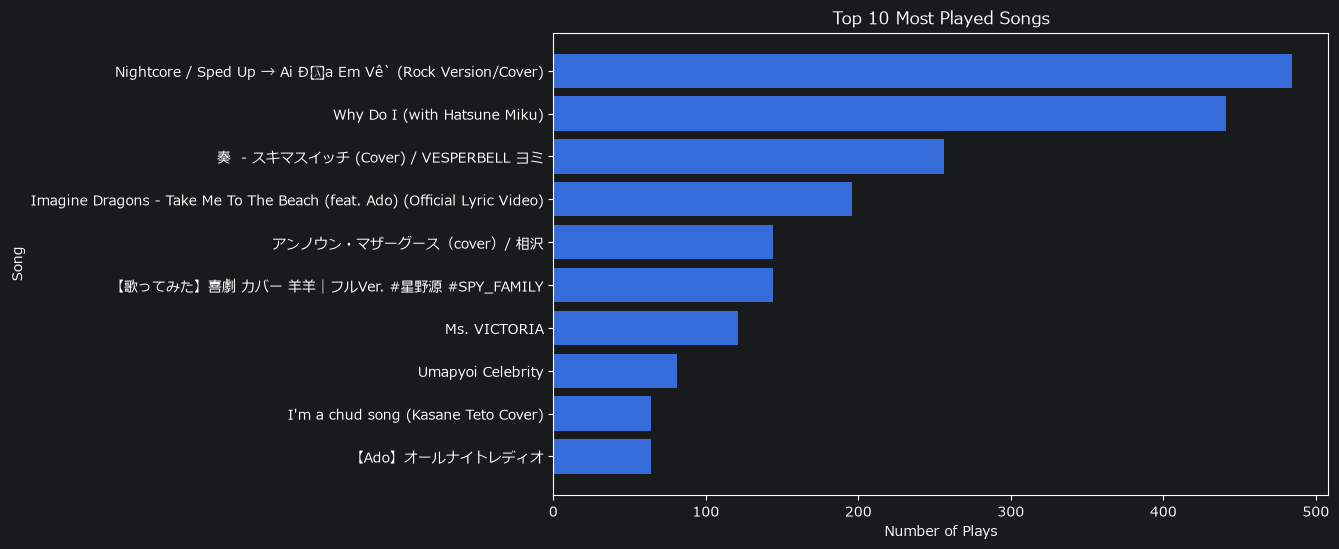

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_songs.index,
    top_10_songs.values
)

plt.xlabel("Number of Plays")
plt.ylabel("Song")
plt.title("Top 10 Most Played Songs")
plt.gca().invert_yaxis()

plt.show()

### Music Listening by Hour

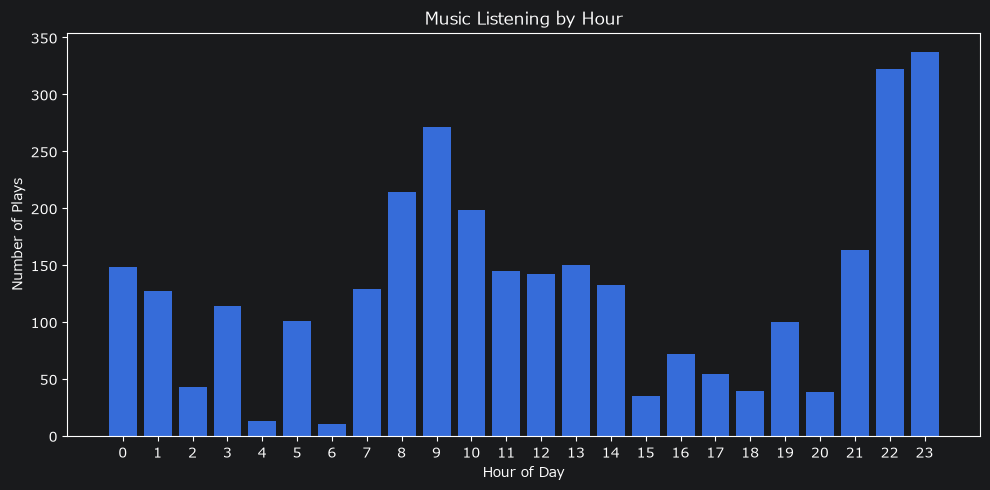

In [49]:
plays_by_hour = (
    music_dataframe["hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    plays_by_hour.index,
    plays_by_hour.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Plays")
plt.title("Music Listening by Hour")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

### Music Listening Over time

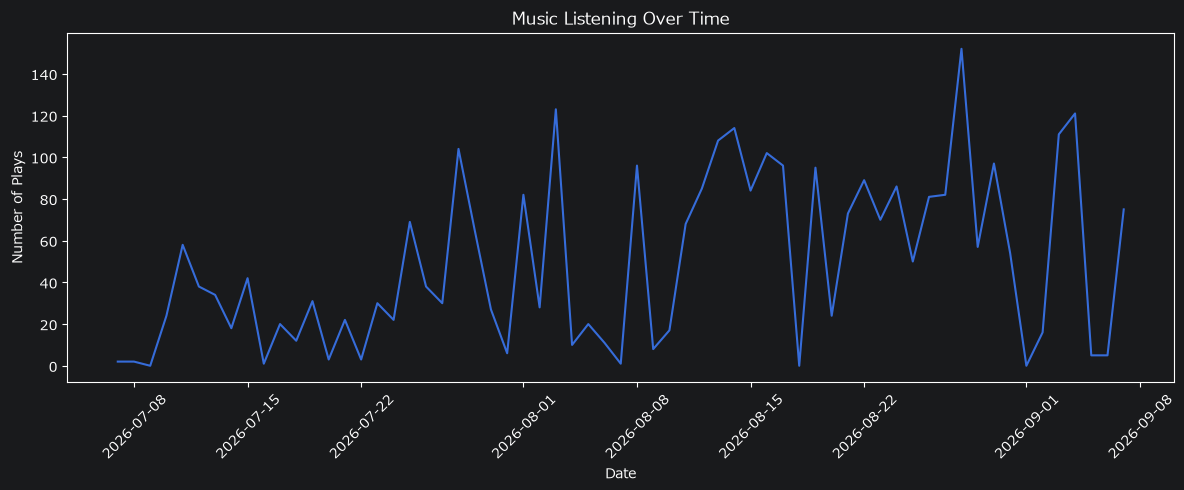

In [50]:
plt.figure(figsize=(12, 5))

all_dates = pd.date_range(
    start=music_dataframe["watched_at"].min().date(),
    end=music_dataframe["watched_at"].max().date()
)

plays_by_date = plays_by_date.reindex(
    all_dates.date,
    fill_value=0
)

plt.plot(
    plays_by_date.index,
    plays_by_date.values
)

plt.xlabel("Date")
plt.ylabel("Number of Plays")
plt.title("Music Listening Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Weekly favourites over time

yeah, just a little chaotic, There's too many songs, likley because its every song that has entered the top 5 being featured

C:\Users\MsnSi\AppData\Local\Temp\ipykernel_29604\3862408038.py:34: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Meiryo.
  plt.tight_layout()
C:\Users\MsnSi\PycharmProjects\Youtube_Music_Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Meiryo.
  fig.canvas.print_figure(bytes_io, **kw)


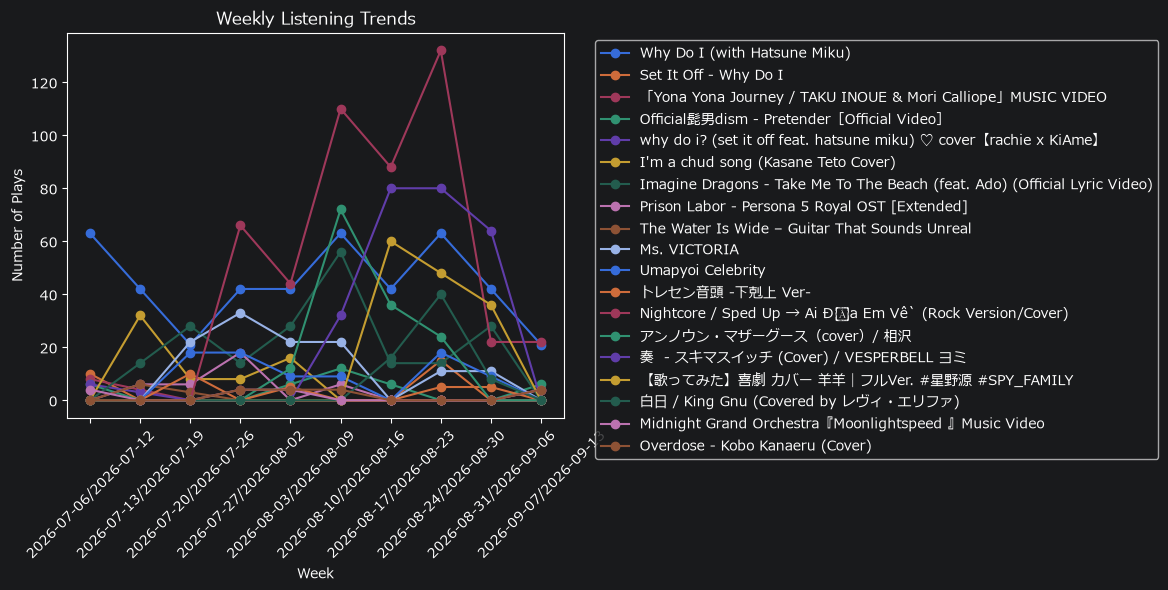

In [51]:
top_weekly_song_names = (
    top_5_weekly
    .index
    .get_level_values("title")
    .unique()
)

weekly_song_table = (
    weekly_song_counts
    .unstack(fill_value=0)
)

weekly_favourites = weekly_song_table[
    top_weekly_song_names
]

plt.figure(figsize=(12, 6))

for song in weekly_favourites.columns:
    plt.plot(
        weekly_favourites.index.astype(str),
        weekly_favourites[song],
        marker="o",
        label=song
    )

plt.xlabel("Week")
plt.ylabel("Number of Plays")
plt.title("Weekly Listening Trends")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### Better version: track the overall Top 5

C:\Users\MsnSi\AppData\Local\Temp\ipykernel_29604\1623538201.py:24: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Meiryo.
  plt.tight_layout()


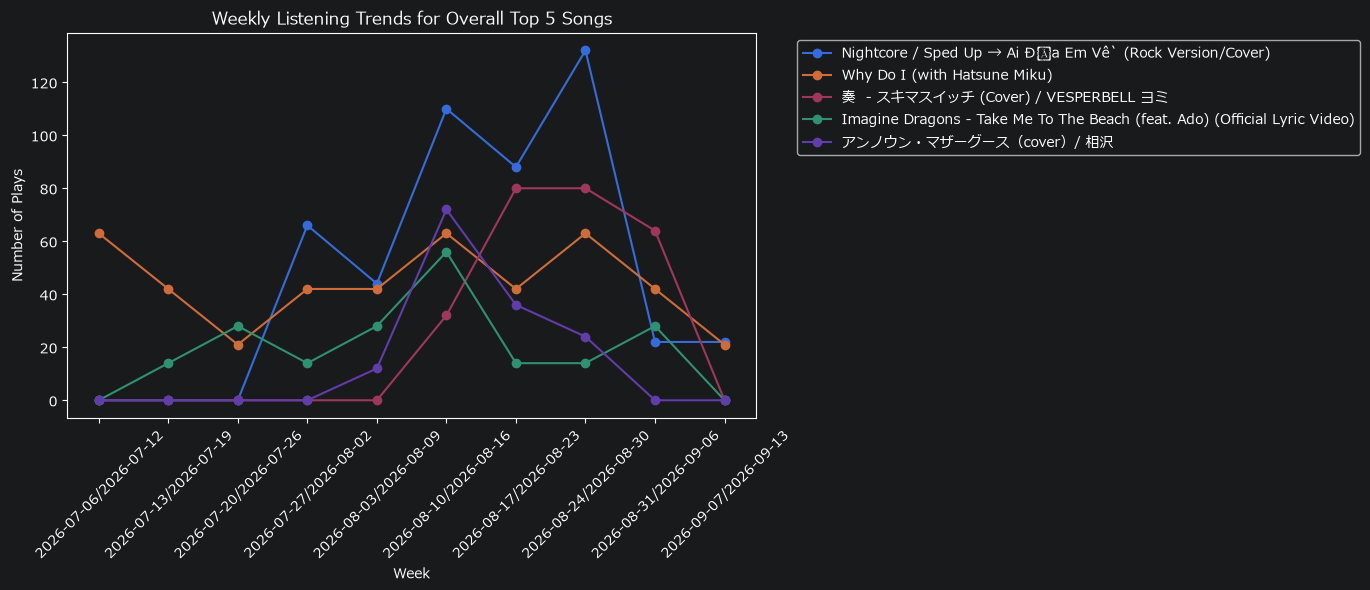

In [52]:
top_5_songs = title_counts.head(5)

top_5_names = top_5_songs.index

weekly_top_5_trends = weekly_song_table[top_5_names]

plt.figure(figsize=(14, 6))

for song in weekly_top_5_trends.columns:
    plt.plot(
        weekly_top_5_trends.index.astype(str),
        weekly_top_5_trends[song],
        marker="o",
        label=song
    )

plt.xlabel("Week")
plt.ylabel("Number of Plays")
plt.title("Weekly Listening Trends for Overall Top 5 Songs")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()